In [ ]:
#Split and Merge

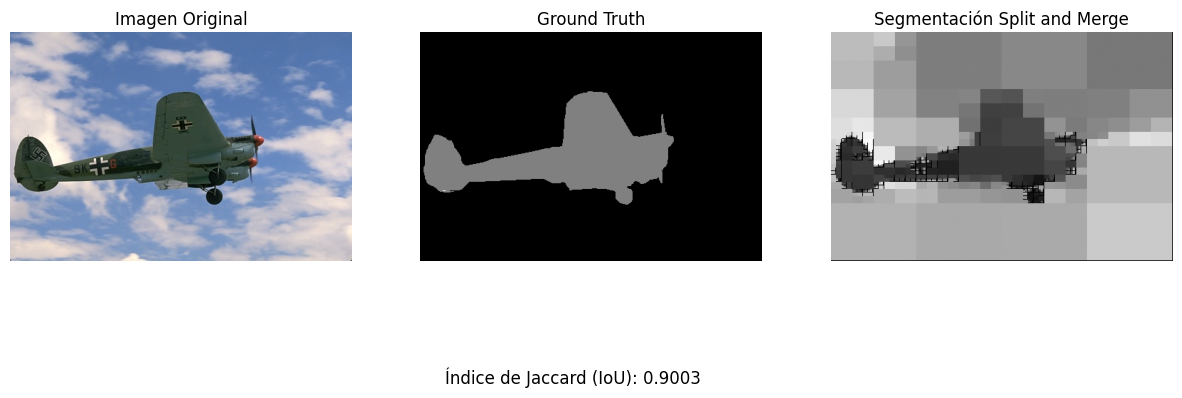

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from PIL import Image

# Rutas de las imágenes
img_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\images\test\3063.jpg"
gt_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\groundTruth\test\3063.mat"

# Cargar imagen
image_pil = Image.open(img_path)
image = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

# Cargar el ground truth
mat_data = sio.loadmat(gt_path)
ground_truth = mat_data['groundTruth'][0, 0]['Segmentation'][0, 0]

# Convertir la imagen a escala de grises
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def homogeneity_criteria(region, threshold=20):
    return np.std(region) < threshold

def split_and_merge(image, min_size=5, threshold=25):
    h, w = image.shape[:2]
    segmented = np.zeros((h, w), dtype=np.uint8)
    
    def split(x, y, width, height):
        region = image[y:y+height, x:x+width]
        if width <= min_size or height <= min_size:
            segmented[y:y+height, x:x+width] = np.mean(region)
            return
        if not homogeneity_criteria(region, threshold):
            half_w, half_h = width // 2, height // 2
            if half_w > 0 and half_h > 0:
                split(x, y, half_w, half_h)
                split(x + half_w, y, half_w, half_h)
                split(x, y + half_h, half_w, half_h)
                split(x + half_w, y + half_h, half_w, half_h)
        else:
            segmented[y:y+height, x:x+width] = np.mean(region)
    
    split(0, 0, w, h)
    return segmented

segmented_image = split_and_merge(image_gray, min_size=3, threshold=30)

# Aplicar morfología para mejorar la segmentación
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))

segmented_post = cv2.morphologyEx(segmented_image, cv2.MORPH_CLOSE, kernel)
segmented_post = cv2.morphologyEx(segmented_post, cv2.MORPH_OPEN, kernel)
segmented_post = cv2.dilate(segmented_post, kernel, iterations=2)
segmented_post = cv2.erode(segmented_post, kernel, iterations=2)

# Binarización con umbral de Otsu
segmented_binary = cv2.adaptiveThreshold(segmented_post, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)
ground_truth_binary = (ground_truth > 0).astype(np.uint8)

def calculate_iou(segmented, ground_truth):
    if segmented.shape != ground_truth.shape:
        ground_truth_resized = cv2.resize(ground_truth, (segmented.shape[1], segmented.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        ground_truth_resized = ground_truth
    intersection = np.logical_and(segmented, ground_truth_resized)
    union = np.logical_or(segmented, ground_truth_resized)
    iou_score = np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0
    
    return iou_score
iou = calculate_iou(segmented_binary, ground_truth_binary)

# Mostrar imágenes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title("Imagen Original")
axes[0].axis("off")

axes[1].imshow(ground_truth, cmap="gray")
axes[1].set_title("Ground Truth")
axes[1].axis("off")

axes[2].imshow(segmented_image, cmap="gray")
axes[2].set_title("Segmentación Split and Merge")
axes[2].axis("off")

plt.figtext(0.5, 0.02, f"Índice de Jaccard (IoU): {iou:.4f}", ha="center", fontsize=12)
plt.show()


In [2]:
#Gradient Vector Flow (GVF)- Flujo de Vectores de Gradiente

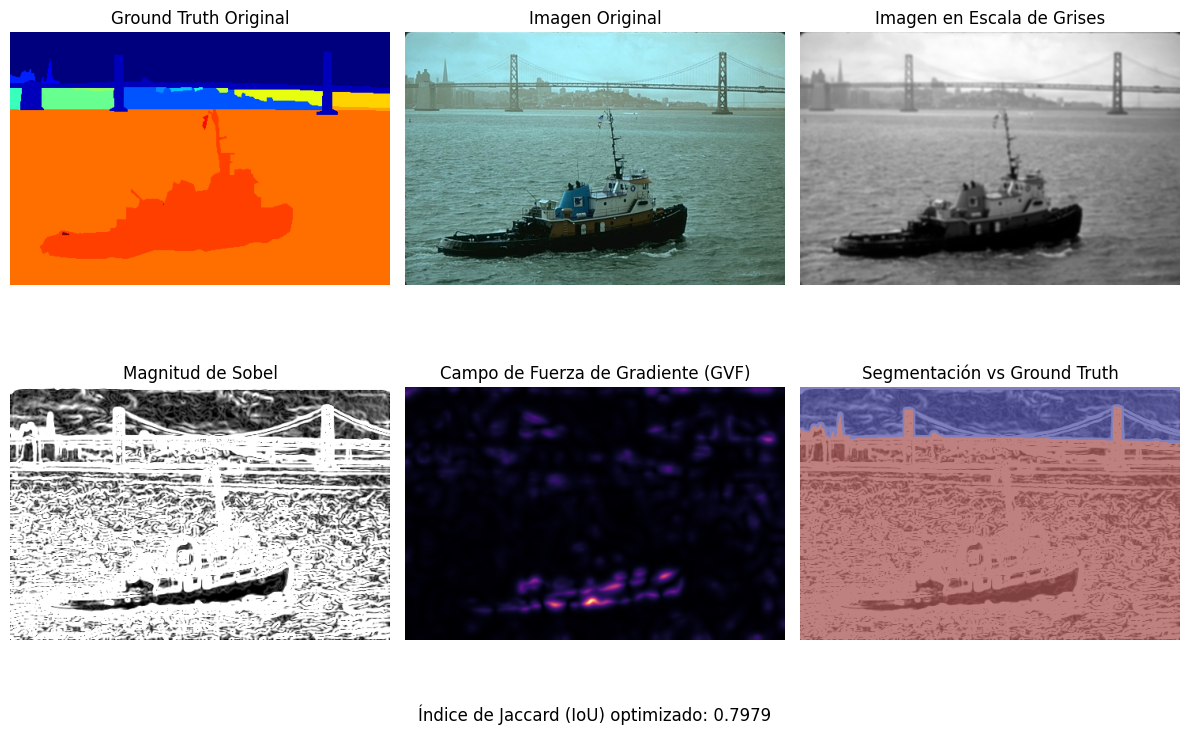

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from PIL import Image
from skimage.segmentation import active_contour

# Rutas de las imágenes
img_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\images\test\48025.jpg"
gt_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\groundTruth\test\48025.mat"

# Cargar la imagen con PIL
image_pil = Image.open(img_path)
image = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

# Convertir a escala de grises y aplicar suavizado
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_gray = cv2.GaussianBlur(image_gray, (5, 5), 1.5)

# Cargar el ground truth
mat_data = sio.loadmat(gt_path)
ground_truth = mat_data['groundTruth'][0, 0]['Segmentation'][0, 0]
ground_truth_binary = (ground_truth > np.min(ground_truth)).astype(np.uint8)

# Aplicar el filtro Sobel
sobel_x = cv2.Sobel(image_gray, cv2.CV_64F, 1, 0, ksize=5)
sobel_y = cv2.Sobel(image_gray, cv2.CV_64F, 0, 1, ksize=5)
sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitude = np.uint8(np.clip(sobel_magnitude, 0, 255))

# Calcular GVF completo (iterativo)
def compute_gvf(edge_map, mu=0.07, iterations=200):
    edge_map = cv2.GaussianBlur(edge_map, (5, 5), 1.5)  # Suavizamos antes de GVF
    edge_map = edge_map.astype(np.float32) / 255.0

    grad_x, grad_y = np.gradient(-edge_map)
    u, v = grad_x.copy(), grad_y.copy()

    for _ in range(iterations):
        laplacian_u = cv2.Laplacian(u, cv2.CV_32F)
        laplacian_v = cv2.Laplacian(v, cv2.CV_32F)

        grad_squared = grad_x**2 + grad_y**2
        grad_squared[grad_squared == 0] = 1e-8  # Evita divisiones por 0

        u += mu * 4 * laplacian_u - (u - grad_x) * grad_squared
        v += mu * 4 * laplacian_v - (v - grad_y) * grad_squared

    gvf_approx = np.sqrt(u**2 + v**2)
    gvf_approx = (gvf_approx - gvf_approx.min()) / (gvf_approx.max() - gvf_approx.min() + 1e-8)

    return gvf_approx, u, v

# Calcular el GVF con la nueva función
gvf_approx, u, v = compute_gvf(sobel_magnitude)

# Mostrar imágenes con mejor distribución
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(ground_truth, cmap='jet')
axes[0, 0].set_title("Ground Truth Original")
axes[0, 0].axis("off")

axes[0, 1].imshow(image, cmap='gray')
axes[0, 1].set_title("Imagen Original")
axes[0, 1].axis("off")

axes[0, 2].imshow(image_gray, cmap='gray')
axes[0, 2].set_title("Imagen en Escala de Grises")
axes[0, 2].axis("off")

axes[1, 0].imshow(sobel_magnitude, cmap='gray')
axes[1, 0].set_title("Magnitud de Sobel")
axes[1, 0].axis("off")

axes[1, 1].imshow(gvf_approx, cmap='magma')  # O usa 'inferno', 'viridis', etc.
axes[1, 1].set_title("Campo de Fuerza de Gradiente (GVF)")
axes[1, 1].axis("off")

axes[1, 2].imshow(sobel_magnitude, cmap='gray', alpha=0.5)
axes[1, 2].imshow(ground_truth_binary, cmap='jet', alpha=0.5)
axes[1, 2].set_title("Segmentación vs Ground Truth")
axes[1, 2].axis("off")

plt.tight_layout()

# Calcular IoU
def calculate_iou(segmented, ground_truth):
    if segmented.shape != ground_truth.shape:
        ground_truth_resized = cv2.resize(ground_truth, (segmented.shape[1], segmented.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        ground_truth_resized = ground_truth
    intersection = np.logical_and(segmented, ground_truth_resized > 0)
    union = np.logical_or(segmented, ground_truth_resized > 0)
    return np.sum(intersection) / np.sum(union) if np.sum(union) > 0 else 0

iou = calculate_iou(sobel_magnitude, ground_truth_binary)

# Agregar el texto del IoU en la parte inferior de la figura principal
fig.text(0.5, 0.02, f"Índice de Jaccard (IoU) optimizado: {iou:.4f}", ha="center", fontsize=12)

# Mostrar la figura completa
plt.show()



In [2]:
#Watershed (Cuencas Hidrograficas)

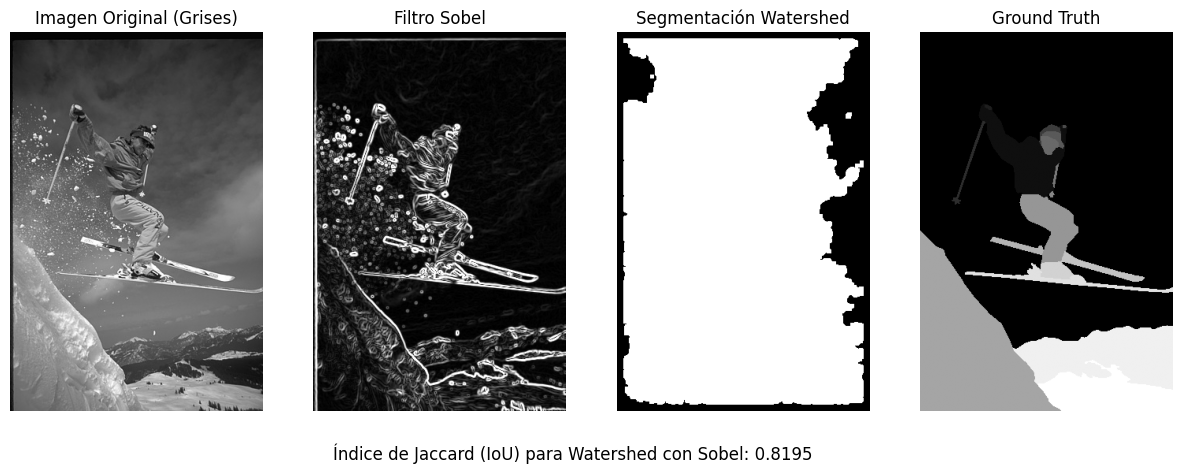

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from PIL import Image

# Rutas de las imágenes
img_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\images\test\225022.jpg"
gt_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\groundTruth\test\225022.mat"

# Cargar imagen
image_pil = Image.open(img_path)
image = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)

# Cargar el ground truth
mat_data = sio.loadmat(gt_path)
ground_truth = mat_data['groundTruth'][0, 0]['Segmentation'][0, 0]

# Convertir a escala de grises
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
image_gray_blur = cv2.GaussianBlur(image_gray, (3, 3), 0)


# Aplicar filtro Sobel
sobel_x = cv2.Sobel(image_gray_blur, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(image_gray_blur, cv2.CV_64F, 0, 1, ksize=3)

sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
sobel_magnitude = cv2.convertScaleAbs(sobel_magnitude)

# Crear marcadores automáticos con thresholding
_, markers_auto = cv2.threshold(sobel_magnitude, 30, 255, cv2.THRESH_BINARY)
markers = np.zeros_like(image_gray, dtype=np.int32)
markers[markers_auto == 255] = 2  # Áreas detectadas con Sobel

# Agregar bordes como marcadores
h, w = image_gray.shape
markers[0:10, :] = 1  # Bordes superiores
markers[h-10:h, :] = 1  # Bordes inferiores
markers[:, 0:10] = 1  # Bordes izquierdos
markers[:, w-10:w] = 1  # Bordes derechos

# Aplicar Watershed
image_rgb = cv2.cvtColor(image_gray, cv2.COLOR_GRAY2BGR)
markers = cv2.watershed(image_rgb, markers)
segmented = markers.copy()
segmented[segmented == -1] = 0
segmented_binary = (segmented > 1).astype(np.uint8)

# Suavizar bordes con dilatación
kernel = np.ones((3, 3), np.uint8)
segmented_binary = cv2.dilate(segmented_binary, kernel, iterations=2)

# Calcular IoU
def calculate_iou(segmented, ground_truth):
    if segmented.shape != ground_truth.shape:
        ground_truth_resized = cv2.resize(ground_truth, (segmented.shape[1], segmented.shape[0]), interpolation=cv2.INTER_NEAREST)
    else:
        ground_truth_resized = ground_truth
    intersection = np.logical_and(segmented, ground_truth_resized > 0)
    union = np.logical_or(segmented, ground_truth_resized > 0)
    iou_score = np.sum(intersection) / np.sum(union)
    return iou_score

ground_truth_binary = (ground_truth > 0).astype(np.uint8)
iou = calculate_iou(segmented_binary, ground_truth_binary)

# Visualizar todas las imágenes
fig, axes = plt.subplots(1, 4, figsize=(15, 5))
axes[0].imshow(image_gray, cmap='gray')
axes[0].axis('off')
axes[0].set_title("Imagen Original (Grises)")

axes[1].imshow(sobel_magnitude, cmap='gray')
axes[1].axis('off')
axes[1].set_title("Filtro Sobel")

axes[2].imshow(segmented_binary, cmap='gray')
axes[2].axis('off')
axes[2].set_title("Segmentación Watershed")

axes[3].imshow(ground_truth, cmap='gray')
axes[3].axis('off')
axes[3].set_title("Ground Truth")

# Agregar el texto del IoU en la parte inferior del gráfico
plt.figtext(0.5, 0.02, f"Índice de Jaccard (IoU) para Watershed con Sobel: {iou:.4f}", ha="center", fontsize=12)

plt.show()



In [ ]:
#Crecimiento de Regiones basado en Grafos (Graph-Based Region Growing)

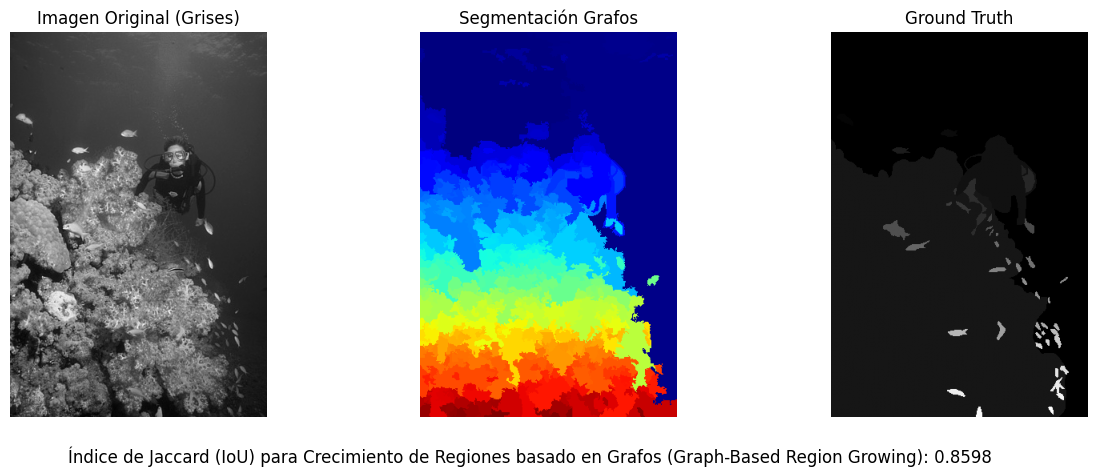

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
import os
from PIL import Image
from skimage.segmentation import felzenszwalb

# Rutas de las imágenes
img_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\images\test\156054.jpg"
gt_path = r"C:\Users\gran_\Documents\Estudio\Especialización Inteligencia Artificial\Segundo semestre\Percepción Computacional\Laboratorio\Laboratorio No. 2\BSR_bsds500\BSR\BSDS500\data\groundTruth\test\156054.mat"

# Verificar si los archivos existen
if not os.path.exists(img_path):
    print(f"Error: El archivo {img_path} no existe en la ruta especificada.")
if not os.path.exists(gt_path):
    print(f"Error: El archivo {gt_path} no existe en la ruta especificada.")

# Cargar la imagen con PIL
try:
    image_pil = Image.open(img_path)
    image = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR)
except Exception as e:
    print(f"Error al cargar la imagen con PIL: {e}")
    image = None

# Cargar el ground truth desde el archivo .mat
mat_data = sio.loadmat(gt_path)
ground_truth = mat_data['groundTruth'][0, 0]['Segmentation'][0, 0]  # Primera segmentación humana

# Validar carga de imágenes
if image is None:
    print(f"Error: No se pudo cargar la imagen en {img_path}")
if ground_truth is None:
    print(f"Error: No se pudo cargar la ground truth en {gt_path}")

# Si ambas imágenes se cargaron, continuar
if image is not None and ground_truth is not None:
    # Convertir a escala de grises para visualización
    image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Aplicar segmentación basada en grafos (Felzenszwalb)
    segmented = felzenszwalb(image, scale=100, sigma=0.5, min_size=50)

    # Binarizar la segmentación (tomar regiones > 0 como objetos)
    segmented_binary = (segmented > 0).astype(np.uint8)

    # Calcular IoU
    def calculate_iou(segmented, ground_truth):
        if segmented.shape != ground_truth.shape:
            ground_truth_resized = cv2.resize(ground_truth, (segmented.shape[1], segmented.shape[0]), interpolation=cv2.INTER_NEAREST)
        else:
            ground_truth_resized = ground_truth
        intersection = np.logical_and(segmented, ground_truth_resized > 0)
        union = np.logical_or(segmented, ground_truth_resized > 0)
        iou_score = np.sum(intersection) / np.sum(union)
        return iou_score

    ground_truth_binary = (ground_truth > 0).astype(np.uint8)
    iou = calculate_iou(segmented_binary, ground_truth_binary)

    # Visualizar resultados: Imagen Original, Segmentación Grafos y Ground Truth
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(image_gray, cmap='gray')
    axes[0].axis('off')
    axes[0].set_title("Imagen Original (Grises)")

    axes[1].imshow(segmented, cmap='jet')
    axes[1].axis('off')
    axes[1].set_title("Segmentación Grafos")

    axes[2].imshow(ground_truth, cmap='gray')
    axes[2].axis('off')
    axes[2].set_title("Ground Truth")

    # Agregar el IoU como texto en la parte inferior de la figura
    plt.figtext(0.5, 0.02, f"Índice de Jaccard (IoU) para Crecimiento de Regiones basado en Grafos (Graph-Based Region Growing): {iou:.4f}", ha="center", fontsize=12)

    plt.show()

